# Treinamento de modelos

```
tensorboard --logdir ./finalProject_outputs/BZA_22_06_2026/runs --port 6006
```

```
nvidia-smi
```

## Configuração de ambiente

In [ ]:
import random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torchvision
from torchvision import transforms

import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "BZA_23_06_2026"
output_dir = Path("finalProject_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 42
Dispositivo: cuda
Versão do Torch: 2.11.0+cu128
Versão do Torchvision: 0.26.0+cu128
Diretório de saída: finalProject_outputs/BZA_22_06_2026


## Importação dos dados

In [2]:
from isic2018_dataset import download_isic2018, get_dataloaders

IMAGE_SIZE = 224
BATCH_SIZE = 64

download_isic2018(root="./data/isic2018")

train_loader, val_loader, test_loader = get_dataloaders(
    root="./data/isic2018",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    train_transform=transforms.ToTensor(),
    val_transform=transforms.ToTensor(),
    test_transform=transforms.ToTensor()
)

✓ Dados já preparados em: /home/al.bianca.abreu/Área de Trabalho/ml2/fine-grained-ml2/data/isic2018 — pulando download/extração.


In [3]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, ConcatDataset

dataset = ConcatDataset([train_loader.dataset, val_loader.dataset])

labels = []
for ds in dataset.datasets:
    if hasattr(ds, "targets"):
        labels.extend(list(ds.targets)) # type: ignore
    elif hasattr(ds, "labels"):
        labels.extend(list(ds.labels)) # type: ignore
    else:
        # fallback (pode ser caro pois itera o dataset)
        labels.extend([lbl for _, lbl in ds])

# Stratified split no dataset concatenado
train_idx, val_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.15,
    stratify=labels,
    random_state=seed,
)

train_subset = Subset(dataset, train_idx)
val_subset = Subset(dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [4]:
NUM_CLASSES = 7

In [5]:
benign = [1, 4, 5, 6]
malignant = [0, 2, 3]

# Cria loaders para a classificação binária

class BinaryDataset(torch.utils.data.Dataset):
    """Wrap any dataset to map multi-class labels into binary (0=benign, 1=malignant)."""
    def __init__(self, base_dataset, benign_classes, malignant_classes):
        self.base = base_dataset
        self.label_map = {}
        for c in benign_classes:
            self.label_map[int(c)] = 0
        for c in malignant_classes:
            self.label_map[int(c)] = 1

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, lbl = self.base[idx]
        # normalize label type
        lbl_val = int(lbl.item()) if isinstance(lbl, torch.Tensor) else int(lbl)
        if lbl_val not in self.label_map:
            raise KeyError(f"Label {lbl_val} not in benign/malignant mapping.")
        return img, self.label_map[lbl_val]

# Cria datasets binários mantendo exatamente as mesmas partições (subsets) usadas antes
train_binary_ds = BinaryDataset(train_loader.dataset, benign, malignant)
val_binary_ds = BinaryDataset(val_loader.dataset, benign, malignant)
test_binary_ds = BinaryDataset(test_loader.dataset, benign, malignant)

# Cria DataLoaders para classificação binária
train_binary_loader = DataLoader(train_binary_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_binary_loader = DataLoader(val_binary_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_binary_loader = DataLoader(test_binary_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

## Funções de treinamento e avaliação

### Funções de treinamento

In [6]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model): # Removeu val_acc
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            return

        # Verifica se a loss de validação diminuiu significativamente
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0  # Reseta o contador se melhorou
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} de {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, model):
        '''Salva o modelo quando há melhora na loss de validação.'''
        import torch
        torch.save(model.state_dict(), self.path)

In [7]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device, epoch_idx=None, writer=None, model_type="model"):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    desc = f"Epoch {epoch_idx}" if epoch_idx else "Train"
    loop = tqdm(loader, desc=desc, leave=False)

    for batch_idx, (inputs, labels) in enumerate(loop, start=1):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)

        predicted_cpu = predicted.cpu()
        labels_cpu = labels.cpu()

        total += labels_cpu.size(0)
        correct += predicted_cpu.eq(labels_cpu).sum().item()

        current_loss = total_loss / total
        current_acc = correct / total
        loop.set_postfix(loss=f"{current_loss:.4f}", acc=f"{current_acc:.4f}")

        if writer is not None:
            global_step = (epoch_idx - 1) * len(loader) + batch_idx if epoch_idx else batch_idx
            writer.add_scalar(f'{model_type}/batch_loss', loss.item(), global_step)
            if batch_idx == 1:
                try:
                    imgs = inputs.detach().cpu()[:4]
                    writer.add_images(f'{model_type}/examples', imgs, epoch_idx)
                except Exception:
                    pass

        del outputs, loss, predicted, inputs, labels, predicted_cpu, labels_cpu
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / total
    return avg_loss, accuracy

In [8]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * inputs.size(0)
        
        _, predicted = outputs.max(1)
        predicted = predicted.cpu()
        labels_cpu = labels.cpu()

        total += labels_cpu.size(0)
        correct += predicted.eq(labels_cpu).sum().item()

        del outputs, loss, predicted, labels, inputs, labels_cpu
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / total
    return avg_loss, accuracy

In [9]:
def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, model_type="", use_early_stopping = True, patience=5, log_every=5, student_run_tag=student_run_tag, output_dir=output_dir):
    from torch.utils.tensorboard import SummaryWriter 
    writer = SummaryWriter(log_dir=f'./{output_dir}/{student_run_tag}/runs/{model_type}')

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    if use_early_stopping:
        early_stopping = EarlyStopping(patience=patience, path=f'./{output_dir}/{student_run_tag}/best_model_{model_type}.pth')

    def _confusion_matrix_figure(y_true, y_pred, class_map=None, normalize=True, cmap='Blues'):
        import numpy as _np
        import matplotlib.pyplot as _plt
        from sklearn.metrics import confusion_matrix as _confusion_matrix

        classes = _np.unique(_np.concatenate([y_true, y_pred]))
        if len(classes) == 0:
            fig = _plt.figure(figsize=(4, 3))
            _plt.text(0.5, 0.5, "No data", ha='center', va='center')
            return fig

        cm = _confusion_matrix(y_true, y_pred, labels=classes, normalize='true' if normalize else None)

        fig, ax = _plt.subplots(figsize=(6, 5))
        im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        if class_map is not None:
            tick_labels = [class_map.get(int(c), str(int(c))) for c in classes]
        else:
            tick_labels = [str(int(c)) for c in classes]

        ax.set_xticks(_np.arange(len(classes)))
        ax.set_yticks(_np.arange(len(classes)))
        ax.set_xticklabels(tick_labels, rotation=45)
        ax.set_yticklabels(tick_labels)

        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.0 if cm.size > 0 else 0.5
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                val = cm[i, j]
                s = f"{val:{fmt}}" if normalize else f"{int(val)}"
                ax.text(j, i, s, ha="center", va="center",
                        color="white" if val > thresh else "black")

        ax.set_ylabel('True label')
        ax.set_xlabel('Predicted label')
        fig.tight_layout()
        return fig

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device,
            epoch_idx=epoch+1, writer=writer, model_type=model_type
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if ((epoch + 1) % log_every == 0) or (epoch + 1 == epochs) or (epoch + 1 == 1):
            print(f"Epoch {epoch+1}/{epochs}: "
                f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

        if use_early_stopping:
            early_stopping(val_loss, model) # type: ignore

        writer.add_scalar(f'{model_type}/train_loss', train_loss, epoch) 
        writer.add_scalar(f'{model_type}/train_acc', train_acc, epoch) 
        writer.add_scalar(f'{model_type}/val_loss', val_loss, epoch) 
        writer.add_scalar(f'{model_type}/val_acc', val_acc, epoch)

        # calcula e registra matriz de confusão da validação no tensorboard
        try:
            import numpy as np
            model.eval()
            y_true = []
            y_pred = []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs = inputs.to(device, non_blocking=True)
                    labels = labels.to(device, non_blocking=True)
                    outputs = model(inputs)

                    if outputs.dim() == 1 or outputs.shape[1] == 1:
                        probs = torch.sigmoid(outputs.view(-1))
                        preds = (probs > 0.5).long().cpu().numpy()
                    else:
                        preds = outputs.argmax(dim=1).cpu().numpy()

                    y_pred.append(preds)
                    y_true.append(labels.cpu().numpy())

                    del outputs, inputs, labels
                    if device.type == 'cuda':
                        torch.cuda.empty_cache()

            if len(y_true) > 0:
                y_true = np.concatenate(y_true)
                y_pred = np.concatenate(y_pred)
                fig = _confusion_matrix_figure(y_true, y_pred, normalize=True)
                writer.add_figure(f'{model_type}/confusion_matrix', fig, epoch)
                import matplotlib.pyplot as plt
                plt.close(fig)
        except Exception as e:
            print(f"Warning: não foi possível registrar matriz de confusão no tensorboard: {e}")

        if use_early_stopping and early_stopping.early_stop: # type: ignore
            print("Early stopping interrompendo o treino...")
            break

    # Carrega o melhor estado do modelo antes de retornar
    # if use_early_stopping:
    #     model.load_state_dict(torch.load(f'./{output_dir}/{student_run_tag}/best_model_{model_type}.pth'))

    writer.close()

    return history

### Funções de avaliação

In [10]:
def compute_metrics(outputs, labels):
    """
    Computa métricas relevantes para classificação como
    acurácia, precisão, recall e F1-score.
    """
    preds = outputs.argmax(dim=1)
    accuracy = (preds == labels).float().mean()
    precision = torch.sum((preds == 1) & (labels == 1)) / (torch.sum(preds == 1) + 1e-8)
    recall = torch.sum((preds == 1) & (labels == 1)) / (torch.sum(labels == 1) + 1e-8)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)

    print(f"Accuracy: {accuracy.item():.4f}")
    print(f"Precision: {precision.item():.4f}")
    print(f"Recall: {recall.item():.4f}")
    print(f"F1 Score: {f1_score.item():.4f}")

In [11]:
def evaluate_classification(model, loader):
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            compute_metrics(outputs, labels)

            del outputs, labels
            if device.type == 'cuda':
                torch.cuda.empty_cache()


In [12]:
def evaluate_classification(model, loader, device=device):
    """
    Avalia o modelo sobre o loader e computa métricas agregadas:
    accuracy, balanced_accuracy, precision/recall/f1 por classe, confusion matrix e ROC AUC (quando aplicável).
    Retorna um dict com as métricas.
    """
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            # trata casos binário (1 saída ou 2 saídas) e multiclass (>=2 saídas)
            if outputs.dim() == 1 or outputs.shape[1] == 1:
                probs = torch.sigmoid(outputs.view(-1))
                preds = (probs > 0.5).long()
                all_probs.append(probs.cpu())
                all_preds.append(preds.cpu())
            else:
                probs_all = torch.softmax(outputs, dim=1)
                preds = outputs.argmax(dim=1)
                # para problema binário multiclass-style, pega prob da classe 1
                if outputs.shape[1] == 2:
                    all_probs.append(probs_all[:, 1].cpu())
                else:
                    all_probs.append(probs_all.cpu())  # multiclass scores, usado apenas se necessário
                all_preds.append(preds.cpu())

            all_labels.append(labels.cpu())

            del outputs, images, labels
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    import numpy as np
    from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                                 precision_recall_fscore_support,
                                 confusion_matrix, roc_auc_score, classification_report)

    y_true = np.concatenate([t.numpy() for t in all_labels])
    y_pred = np.concatenate([t.numpy() for t in all_preds])

    metrics = {}
    metrics['accuracy'] = float(accuracy_score(y_true, y_pred))
    metrics['balanced_accuracy'] = float(balanced_accuracy_score(y_true, y_pred))

    # per-class precision/recall/f1 and support
    precisions, recalls, f1s, supports = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    per_class = {}
    classes = np.unique(np.concatenate([y_true, y_pred]))
    for i, cls in enumerate(classes):
        per_class[int(cls)] = {
            'precision': float(precisions[i]), # type: ignore
            'recall': float(recalls[i]), # type: ignore
            'f1': float(f1s[i]), # type: ignore
            'support': int(supports[i]) # type: ignore
        }
    metrics['per_class'] = per_class

    # aggregated macro/binary metrics
    avg = 'binary' if len(classes) == 2 else 'macro'
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=avg, zero_division=0)
    metrics.update({'precision': float(precision), 'recall': float(recall), 'f1': float(f1)})

    metrics['confusion_matrix'] = confusion_matrix(y_true, y_pred).tolist()

    # tenta ROC AUC quando for binário e tivermos scores adequados
    try:
        if len(all_probs) > 0:
            probs_cat = np.concatenate([p.numpy() for p in all_probs])
            if probs_cat.ndim == 1:
                metrics['roc_auc'] = float(roc_auc_score(y_true, probs_cat))
            elif probs_cat.ndim == 2 and probs_cat.shape[1] == 2:
                metrics['roc_auc'] = float(roc_auc_score(y_true, probs_cat[:, 1]))
            else:
                metrics['roc_auc'] = None
        else:
            metrics['roc_auc'] = None
    except Exception:
        metrics['roc_auc'] = None

    # relatório resumido
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"Precision ({avg}): {metrics['precision']:.4f}")
    print(f"Recall ({avg}): {metrics['recall']:.4f}")
    print(f"F1 ({avg}): {metrics['f1']:.4f}")
    if metrics['roc_auc'] is not None:
        print(f"ROC AUC: {metrics['roc_auc']:.4f}")
    print("Confusion matrix:")
    print(np.array(metrics['confusion_matrix']))
    print("Per-class metrics:")
    for cls, m in metrics['per_class'].items():
        print(f" Class {cls}: precision={m['precision']:.3f}, recall={m['recall']:.3f}, f1={m['f1']:.3f}, support={m['support']}")

    return metrics

In [13]:
def plot_roc(model, loader, device, type='binary'):
    """
    Plota a curva ROC para o modelo.
    """
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize

    y_true = []
    y_scores = []

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            # mover tensores para o mesmo device do modelo
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            # calcula probabilidades compatíveis com binário/multiclass
            if outputs.dim() == 1 or outputs.shape[1] == 1:
                probs = torch.sigmoid(outputs.view(-1)).cpu().numpy()
                y_scores.extend(probs)
            else:
                probs_all = torch.softmax(outputs, dim=1)
                if outputs.shape[1] == 2:
                    probs = probs_all[:, 1].cpu().numpy()
                    y_scores.extend(probs)
                else:
                    # multiclass: armazena todas as probabilidades (por classe)
                    # aqui acumulamos por batch; converteremos depois para array NxC
                    y_scores.extend(probs_all.cpu().numpy())

            y_true.extend(labels.cpu().numpy())

            del outputs, images, labels
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    import numpy as np

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    if type == 'multiclass':
        n_classes = NUM_CLASSES
        # espera y_scores shape (N, C)
        if y_scores.ndim == 1:
            raise RuntimeError("Esperado scores multiclass NxC, mas recebeu vetor unidimensional.")
        y_test_bin = label_binarize(y_true, classes=np.arange(n_classes))
        fpr = dict(); tpr = dict(); roc_auc = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_scores[:, i]) # type: ignore
            roc_auc[i] = auc(fpr[i], tpr[i])
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_scores.ravel()) # type: ignore
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        plt.figure(figsize=(10, 8))
        plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})', color='deeppink', linestyle=':', linewidth=4)
        colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'black']
        for i, color in zip(range(n_classes), colors):
            plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} ROC (AUC = {roc_auc[i]:.2f})')
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.title('Multi-class One-vs-Rest (OvR) ROC Curve'); plt.legend(loc="lower right"); plt.grid(True)
        plt.show()

    else:
        # binário: y_scores deve ser vetor com prob da classe positiva
        if y_scores.ndim > 1:
            # se acumulamos matrizes por batch, podem precisar pegar coluna 1
            if y_scores.shape[1] == 2:
                y_scores = y_scores[:, 1]
            else:
                raise RuntimeError("Scores com dimensão inesperada para ROC binário.")
        fpr, tpr, thresholds = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC)'); plt.legend(loc="lower right"); plt.show()

In [14]:
def plot_eval(history, model_name, student_run_tag=student_run_tag):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    metrics = [('loss', 'Loss'), ('acc', 'Accuracy')]

    for i, (key, label) in enumerate(metrics):
        ax = axes[i]

        ax.plot(history[f'train_{key}'], label=f'Train {label}', color='darkorchid', lw=2)
        ax.plot(history[f'val_{key}'], label=f'Validation {label}', color='seagreen', lw=2)

        ax.set_title(f'Training and Validation {label} ({model_name.upper()})')
        ax.set_xlabel('Epochs')
        ax.set_ylabel(label)
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()

    save_dir = f'./{output_dir}/{student_run_tag}'
    file_path = f'{save_dir}/evaluation_curves_{model_name}.png'
    plt.savefig(file_path)
    plt.show()
    print(f'Painel de avaliação salvo em: {file_path}')

In [15]:
def plot_confusion_matrix(model, loader, device, classes=None, normalize=False, figsize=(8,6), cmap='Blues', class_map=None):
    """
    Calcula e plota a matriz de confusão para `model` sobre `loader`.
    ...
    """
    import numpy as np
    from sklearn.metrics import confusion_matrix
    import matplotlib.pyplot as plt

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            # Decide predicões a partir da saída do modelo
            if outputs.dim() == 1 or outputs.shape[1] == 1:
                probs = torch.sigmoid(outputs.view(-1))
                preds = (probs > 0.5).long().cpu().numpy()
            else:
                preds = outputs.argmax(dim=1).cpu().numpy()

            y_pred.append(preds)
            y_true.append(labels.cpu().numpy())

            del outputs, images, labels
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # Decide classes e rótulos a mostrar nos eixos
    if class_map is not None:
        # Normaliza class_map para inv_map: int_index -> name_str
        inv_map = {}
        for k, v in class_map.items():
            # tenta tratar chave como índice (int -> name)
            try:
                idx = int(k)
                inv_map[idx] = str(v)
                continue
            except Exception:
                pass
            # tenta tratar valor como índice (name -> int)
            try:
                idx = int(v)
                inv_map[idx] = str(k)
                continue
            except Exception:
                pass
            raise ValueError("class_map deve mapear int->str (ex: {0:'benigno'}) ou str->int (ex: {'benigno':0}).")
        ordered_indices = sorted(inv_map.keys())
        if classes is None:
            classes = ordered_indices
        # tick labels na mesma ordem das classes
        tick_labels = [inv_map.get(c, str(c)) for c in classes]
    else:
        # sem class_map: comportamento anterior
        if classes is None:
            try:
                classes = list(range(NUM_CLASSES))
            except Exception:
                classes = np.unique(np.concatenate([y_true, y_pred])).tolist()
        # se classes são ints, usa-os como rótulos simples
        tick_labels = [str(c) for c in classes]

    cm = confusion_matrix(y_true, y_pred, labels=classes, normalize='true' if normalize else None)

    plt.figure(figsize=figsize)
    im = plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title('Confusion matrix' + (' (normalized)' if normalize else ''))
    plt.colorbar(im, fraction=0.046, pad=0.04)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, tick_labels, rotation=45)
    plt.yticks(tick_marks, tick_labels)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.0 if cm.size > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            if normalize:
                s = f"{val:.2f}"
            else:
                s = f"{int(val)}"
            plt.text(j, i, s,
                     horizontalalignment="center",
                     color="white" if val > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    return cm

## Modelos com conexões residuais

### Arquitetura

[Código retirado](https://medium.com/biased-algorithms/building-resnet18-from-scratch-using-pytorch-64c6619432f2)

In [16]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        
        # Apply the first convolution, batch norm, and ReLU activation
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Apply the second convolution and batch norm
        out = self.conv2(out)
        out = self.bn2(out)

        # Handle downsampling if required
        if self.downsample is not None:
            identity = self.downsample(x)
        
        # Add skip connection
        out += identity
        out = self.relu(out)

        return out

In [17]:
def initialize_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

In [18]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Define the layers based on ResNet-18 architecture
        self.layer1 = self._make_layer(64, 2)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
        
        # Initialize weights
        self.apply(initialize_weights)
        
    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        layers = [ResidualBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x

### Modelo baseline

In [19]:
NUM_CLASSES = 2
model_resnet = ResNet18(num_classes=NUM_CLASSES).to(device)

epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet.parameters(), lr=1e-3)

summary(model_resnet, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
    ResidualBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [20]:
history_resnet = fit(model_resnet, train_binary_loader, val_binary_loader, optimizer, criterion, device, epochs, 'resnet', False)

Epoch 1/50: Train Loss: 0.4397 | Acc: 0.8005 | Val Loss: 0.4375 | Acc: 0.8048


Epoch 5/50: Train Loss: 0.3842 | Acc: 0.8033 | Val Loss: 0.3963 | Acc: 0.7807


Epoch 10/50: Train Loss: 0.3705 | Acc: 0.8126 | Val Loss: 0.3822 | Acc: 0.8081


Epoch 15/50: Train Loss: 0.3444 | Acc: 0.8336 | Val Loss: 0.3958 | Acc: 0.8114


Epoch 20/50: Train Loss: 0.3281 | Acc: 0.8388 | Val Loss: 0.3474 | Acc: 0.8303


...

Epoch 30/50: Train Loss: 0.3019 | Acc: 0.8601 | Val Loss: 0.4129 | Acc: 0.8205


Epoch 35/50: Train Loss: 0.2960 | Acc: 0.8665 | Val Loss: 0.3361 | Acc: 0.8407


Epoch 40/50: Train Loss: 0.2482 | Acc: 0.8891 | Val Loss: 0.3499 | Acc: 0.8427


Epoch 45/50: Train Loss: 0.1557 | Acc: 0.9374 | Val Loss: 0.4225 | Acc: 0.8486


Epoch 50/50: Train Loss: 0.0694 | Acc: 0.9725 | Val Loss: 0.6570 | Acc: 0.8414


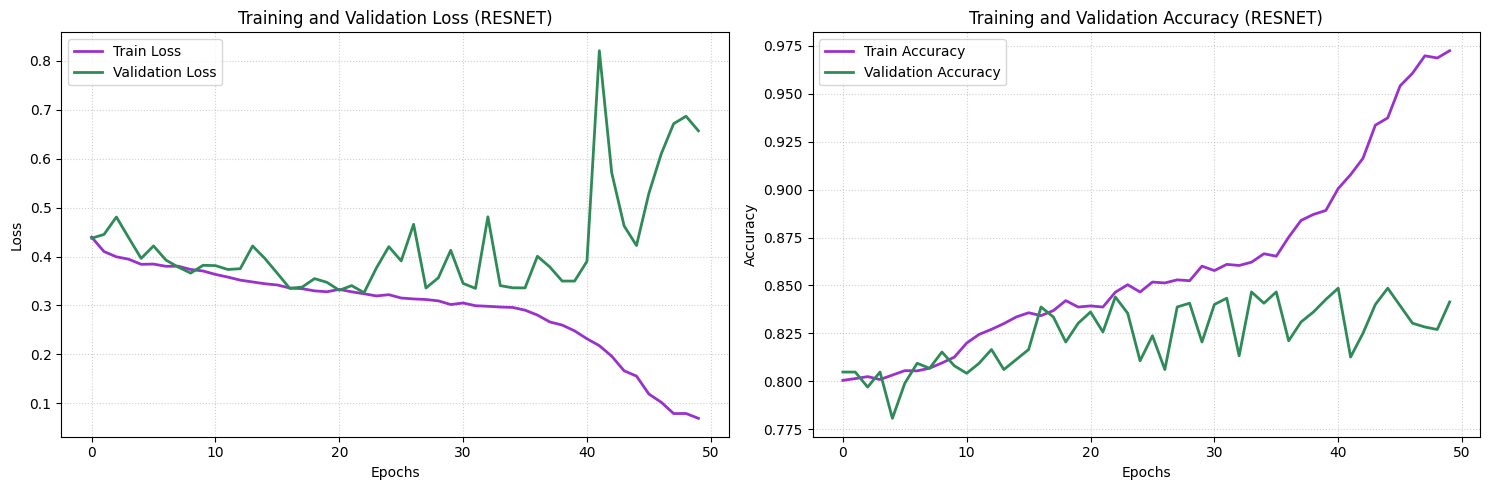

Painel de avaliação salvo em: ./finalProject_outputs/BZA_22_06_2026/evaluation_curves_resnet.png


In [21]:
torch.save(model_resnet.state_dict(), f'./{output_dir}/{student_run_tag}/model_resnet.pth')
plot_eval(history_resnet, 'resnet')

In [22]:
_ = evaluate_classification(model_resnet, test_binary_loader)

Accuracy: 0.8029
Balanced Accuracy: 0.6567
Precision (binary): 0.5185
Recall (binary): 0.4104
F1 (binary): 0.4582
ROC AUC: 0.8009
Confusion matrix:
[[1088  117]
 [ 181  126]]
Per-class metrics:
 Class 0: precision=0.857, recall=0.903, f1=0.880, support=1205
 Class 1: precision=0.519, recall=0.410, f1=0.458, support=307


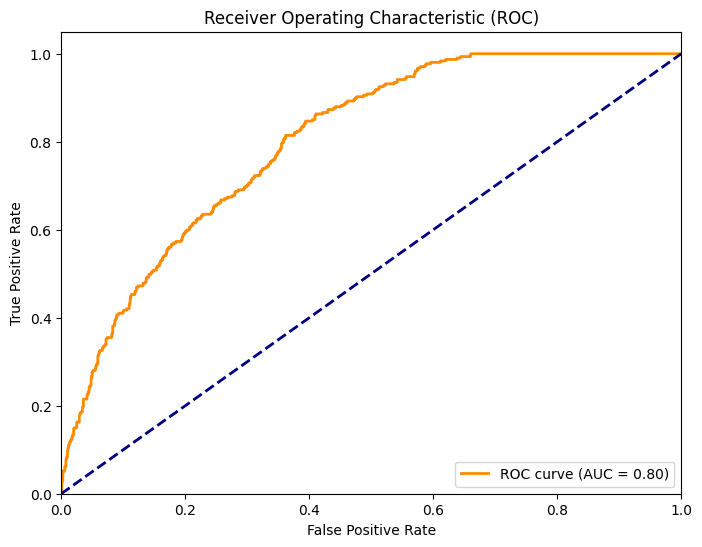

In [23]:
plot_roc(model_resnet, test_binary_loader, device, type='binary')

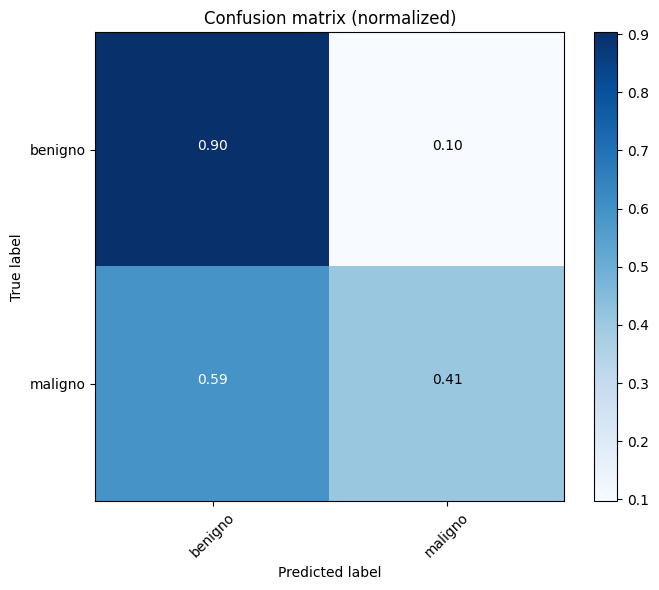

array([[0.90290456, 0.09709544],
       [0.58957655, 0.41042345]])

In [24]:
plot_confusion_matrix(model_resnet, test_binary_loader, device, classes=[0, 1], normalize=True, class_map={0: 'benigno', 1: 'maligno'})

### Normalizando o dado de entrada

#### Criando data loaders normalizados

In [19]:
# python
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import numpy as np

mean = torch.zeros(3)
std = torch.zeros(3)
nb_samples = 0

for imgs, _ in train_binary_loader:
    batch = imgs.size(0)
    imgs = imgs.view(batch, imgs.size(1), -1)  # (B, C, H*W)
    mean += imgs.mean(2).sum(0)
    std += imgs.std(2).sum(0)
    nb_samples += batch

mean /= nb_samples
std /= nb_samples

print('mean =', mean.numpy().tolist())
print('std  =', std.numpy().tolist())

mean = [0.7635358572006226, 0.5469121336936951, 0.5714287161827087]
std  = [0.08929696679115295, 0.11819677799940109, 0.13290563225746155]


In [20]:
norm_transform = transforms.Compose([
    transforms.Normalize(mean=mean.numpy().tolist(), std=std.numpy().tolist()),
])

from torch.utils.data import Dataset

class ApplyTransform(Dataset):
    """
    Envelopa um dataset existente para aplicar uma transformação específica
    sem modificar o dataset original.
    """
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.dataset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.dataset)

In [21]:
norm_train_binary_dataset = ApplyTransform(train_binary_loader.dataset, transform=norm_transform)
norm_val_binary_dataset = ApplyTransform(val_binary_loader.dataset, transform=norm_transform)
norm_test_binary_dataset = ApplyTransform(test_binary_loader.dataset, transform=norm_transform)

norm_train_binary_loader = DataLoader(
    dataset=norm_train_binary_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

norm_val_binary_loader = DataLoader(
    dataset=norm_val_binary_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

norm_test_binary_loader = DataLoader(
    dataset=norm_test_binary_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

#### Modelo com dados normalizados

In [45]:
NUM_CLASSES = 2
model_resnet2 = ResNet18(num_classes=NUM_CLASSES).to(device)

epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet2.parameters(), lr=1e-3)

In [46]:
history_resnet2 = fit(model_resnet2, norm_train_binary_loader, norm_val_binary_loader, optimizer, criterion, device, epochs, 'resnet_norm', True, patience=10)

Epoch 1/50: Train Loss: 0.4369 | Acc: 0.7915 | Val Loss: 0.4175 | Acc: 0.7937


EarlyStopping counter: 1 de 10


EarlyStopping counter: 2 de 10


Epoch 5/50: Train Loss: 0.3984 | Acc: 0.8005 | Val Loss: 0.3973 | Acc: 0.8029
EarlyStopping counter: 1 de 10


EarlyStopping counter: 2 de 10


...

Epoch 45/50: Train Loss: 0.2223 | Acc: 0.9034 | Val Loss: 0.3647 | Acc: 0.8388
EarlyStopping counter: 6 de 10


EarlyStopping counter: 7 de 10


EarlyStopping counter: 8 de 10


EarlyStopping counter: 9 de 10


EarlyStopping counter: 10 de 10
Early stopping interrompendo o treino...


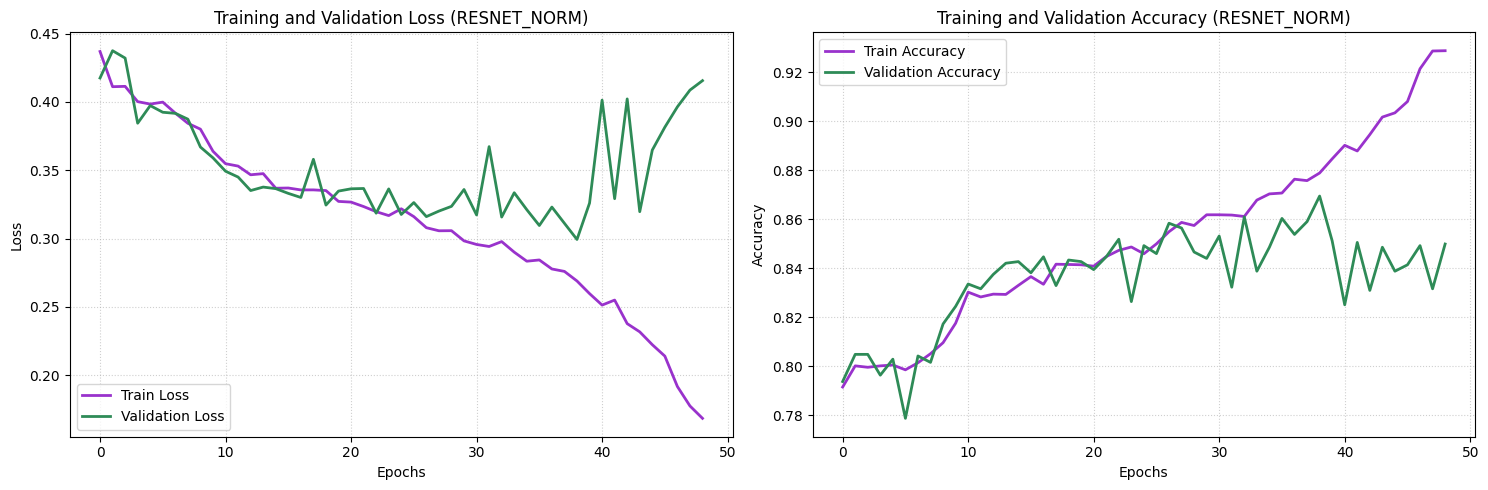

Painel de avaliação salvo em: ./finalProject_outputs/BZA_22_06_2026/evaluation_curves_resnet_norm.png


In [47]:
torch.save(model_resnet2.state_dict(), f'./{output_dir}/{student_run_tag}/model_resnet_norm.pth')
plot_eval(history_resnet2, 'resnet_norm')

In [48]:
best_resnet_norm = ResNet18(num_classes=2).to(device)
best_resnet_norm.load_state_dict(torch.load(f'./{output_dir}/{student_run_tag}/best_model_resnet_norm.pth', map_location=device))

_ = evaluate_classification(best_resnet_norm, norm_test_binary_loader)

Accuracy: 0.8505
Balanced Accuracy: 0.7290
Precision (binary): 0.6680
Recall (binary): 0.5244
F1 (binary): 0.5876
ROC AUC: 0.8731
Confusion matrix:
[[1125   80]
 [ 146  161]]
Per-class metrics:
 Class 0: precision=0.885, recall=0.934, f1=0.909, support=1205
 Class 1: precision=0.668, recall=0.524, f1=0.588, support=307


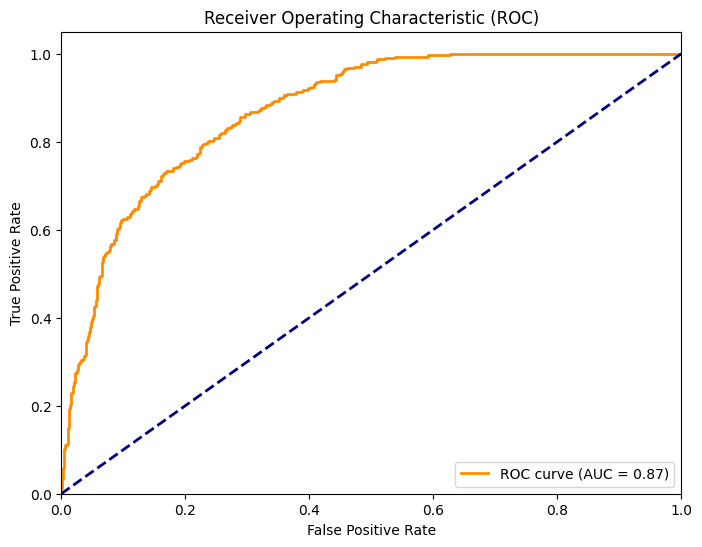

In [49]:
plot_roc(best_resnet_norm, norm_test_binary_loader, device, type='binary')

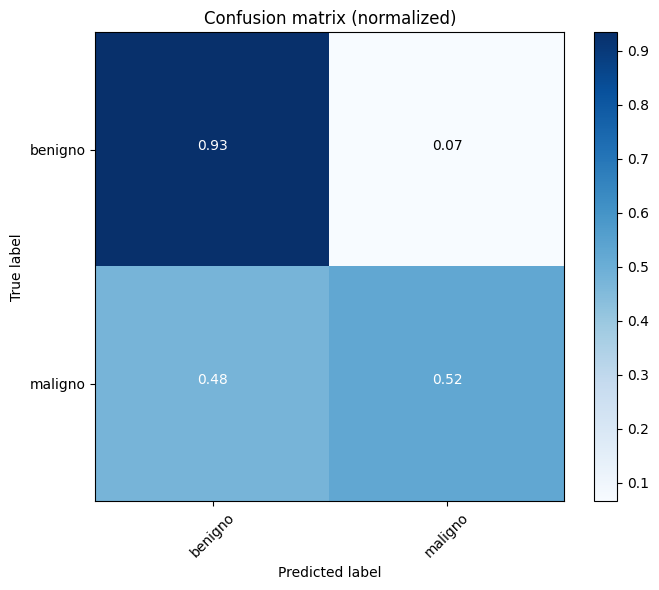

array([[0.93360996, 0.06639004],
       [0.47557003, 0.52442997]])

In [50]:
plot_confusion_matrix(best_resnet_norm, norm_test_binary_loader, device, classes=[0, 1], normalize=True, class_map={0: 'benigno', 1: 'maligno'})

### Testando com BCELoss

In [34]:
NUM_CLASSES = 1
model_resnet3 = ResNet18(num_classes=NUM_CLASSES).to(device)

epochs = 50
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_resnet3.parameters(), lr=1e-3)

In [ ]:
history_resnet3 = fit(model_resnet3, norm_train_binary_loader, norm_val_binary_loader, optimizer, criterion, device, epochs, 'resnet_bce', True, patience=10)

In [ ]:
torch.save(model_resnet3.state_dict(), f'./{output_dir}/{student_run_tag}/model_resnet_bce.pth')
plot_eval(history_resnet3, 'resnet_bce')

In [ ]:
_ = evaluate_classification(model_resnet3, test_binary_loader)

In [ ]:
plot_roc(model_resnet3, test_binary_loader, device, type='binary')

In [ ]:
plot_confusion_matrix(model_resnet3, test_binary_loader, device, classes=[0, 1], normalize=True, class_map={0: 'benigno', 1: 'maligno'})

## Mitigando o overfitting

Analisando a matriz de confusão por época e tendo ciência da proporção das classes e o desbalanceamento do dataset. Vemos que o modelo fica um tanto limitado aos dados benignos que compõe a maioria do dataset, o que implica em um desempenho indesejável quando analisamos as métricas por classe.

### Adicionando visualizações perinentes

In [ ]:
def plot_top_errors(model, loader, device, num_images=5, class_names=['Benigno', 'Maligno'], mean=mean.numpy(), std=std.numpy()):
    """
    Percorre o DataLoader, identifica os piores erros da rede e retorna uma figura Matplotlib.
    """
    model.eval()
    
    # Armazenar erros: (confiança_no_erro, imagem_cpu, probabilidade_maligno)
    false_positives = [] 
    false_negatives = [] 
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(inputs)
            
            if outputs.dim() == 1 or outputs.shape[1] == 1:
                probs = torch.sigmoid(outputs.view(-1))
            else:
                probs = torch.softmax(outputs, dim=1)[:, 1]
                
            preds = (probs > 0.5).long()
            
            # Avalia cada imagem do batch
            for i in range(len(labels)):
                true_y = labels[i].item()
                pred_y = preds[i].item()
                prob_maligno = probs[i].item()
                
                if true_y == 0 and pred_y == 1:
                    # FP: Era Benigno. O quão grave é o erro? Quanto mais perto de 1.0 (100%), pior.
                    false_positives.append((prob_maligno, inputs[i].detach().cpu(), prob_maligno))
                    
                elif true_y == 1 and pred_y == 0:
                    # FN: Era Maligno. O quão grave é o erro? Quanto mais perto de 0.0, pior.
                    # Usamos (1 - prob_maligno) para que erros piores tenham valores maiores, facilitando a ordenação.
                    false_negatives.append((1 - prob_maligno, inputs[i].detach().cpu(), prob_maligno))
                    
    # Ordena de forma decrescente pela gravidade do erro
    false_positives.sort(key=lambda x: x[0], reverse=True)
    false_negatives.sort(key=lambda x: x[0], reverse=True)
    
    # Pega apenas o top K solicitado
    top_fp = false_positives[:num_images]
    top_fn = false_negatives[:num_images]
    
    # Prepara a figura
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 3, 6))
    if num_images == 1:
        axes = np.expand_dims(axes, axis=1) # Ajuste para num_images=1 não quebrar os índices
        
    def imshow(img_tensor, ax, title):
        # Converte de tensor (C, H, W) para numpy (H, W, C)
        img = img_tensor.numpy().transpose((1, 2, 0))

        img = std * img + mean

        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(title, fontsize=10, color='darkred')
        ax.axis('off')

    # Plotando os Falsos Positivos (Linha Superior)
    axes[0, 0].set_ylabel('Falsos Positivos', fontsize=12, weight='bold') # Label da linha
    for i in range(num_images):
        if i < len(top_fp):
            _, img, prob = top_fp[i]
            imshow(img, axes[0, i], f"FP (Real: {class_names[0]})\nPreviu Maligno com {prob:.1%}")
        else:
            axes[0, i].axis('off')
            
    # Plotando os Falsos Negativos (Linha Inferior)
    axes[1, 0].set_ylabel('Falsos Negativos', fontsize=12, weight='bold') # Label da linha
    for i in range(num_images):
        if i < len(top_fn):
            _, img, prob = top_fn[i]
            # Probabilidade próxima de 0, significa que o modelo estava confiante que era benigno
            imshow(img, axes[1, i], f"FN (Real: {class_names[1]})\nPreviu Benigno com {prob:.1%}")
        else:
            axes[1, i].axis('off')

    plt.tight_layout()
    return fig

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget, BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def plot_gradcam(model, loader, device, num_images=4, is_binary_loss=False, mean=mean.numpy(), std=std.numpy()):
    model.eval()
    
    # 1. Define a camada alvo da ResNet
    target_layers = [model.layer4[-1]]
    
    # 2. Inicializa o GradCAM
    cam = GradCAM(model=model, target_layers=target_layers)
    
    # Define o alvo: Queremos ver o que faz a rede pensar que é "Maligno" (Classe 1)
    if is_binary_loss: # Se estiver usando BCEWithLogitsLoss (saída de 1 dimensão)
        targets = [BinaryClassifierOutputTarget(1)] * num_images
    else:              # Se estiver usando CrossEntropyLoss (saída de 2 dimensões)
        targets = [ClassifierOutputTarget(1)] * num_images

    # Pega um batch de validação
    inputs, labels = next(iter(loader))
    inputs = inputs[:num_images].to(device)
    labels = labels[:num_images]

    # 3. Gera os mapas de ativação (retorna um array numpy)
    grayscale_cams = cam(input_tensor=inputs, targets=targets) # type: ignore

    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 4, 4))
    if num_images == 1:
        axes = [axes]

    for i in range(num_images):
        # 4. Desnormaliza a imagem do PyTorch para exibição RGB
        
        img_tensor = inputs[i].detach().cpu().numpy().transpose((1, 2, 0))
        img_rgb = std * img_tensor + mean
        img_rgb = np.clip(img_rgb, 0, 1) # Garante que os pixels fiquem entre 0 e 1

        # 5. Sobrepõe o mapa de calor na imagem original
        cam_image = show_cam_on_image(img_rgb, grayscale_cams[i, :], use_rgb=True)

        true_label = "Maligno" if labels[i].item() == 1 else "Benigno"
        
        axes[i].imshow(cam_image)
        axes[i].set_title(f"Real: {true_label}\nMapa de Ativação (Maligno)")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
    
    # Importante: limpar memória da GPU ocupada pelos hooks do GradCAM
    del cam

In [ ]:
def log_gradcam_tensorboard(writer, model, loader, device, epoch, model_type="model", num_images=4, is_binary_loss=False, mean=mean.numpy(), std=std.numpy()):
    model.eval()
    target_layers = [model.layer4[-1]]
    
    # O GradCAM adiciona 'hooks' ao modelo. Usar with garante que eles sejam limpos depois.
    with GradCAM(model=model, target_layers=target_layers) as cam:
        
        if is_binary_loss:
            targets = [BinaryClassifierOutputTarget(1)] * num_images
        else:
            targets = [ClassifierOutputTarget(1)] * num_images

        inputs, labels = next(iter(loader))
        inputs = inputs[:num_images].to(device)
        
        grayscale_cams = cam(input_tensor=inputs, targets=targets) # type: ignore
        
        cam_images_tensor = []
        
        for i in range(num_images):
            # Desnormalização
            img_tensor = inputs[i].detach().cpu().numpy().transpose((1, 2, 0))
            img_rgb = std * img_tensor + mean
            img_rgb = np.clip(img_rgb, 0, 1)

            # Sobreposição
            cam_image = show_cam_on_image(img_rgb, grayscale_cams[i, :], use_rgb=True)
            
            # Converte de volta para Tensor (C, H, W) para o TensorBoard e normaliza para [0, 1]
            cam_image_tensor = torch.from_numpy(cam_image).permute(2, 0, 1).float() / 255.0
            cam_images_tensor.append(cam_image_tensor)
            
        # Cria um grid com as imagens lado a lado
        grid = torchvision.utils.make_grid(cam_images_tensor, nrow=num_images)
        writer.add_image(f'{model_type}/Visuals/GradCAM_Maligno', grid, epoch)

In [ ]:
from sklearn.metrics import roc_curve, auc

def log_roc_curve(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(6, 5))

    ax.plot(
        fpr,
        tpr,
        label=f'ROC AUC = {roc_auc:.4f}'
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        alpha=0.7,
        label='Random'
    )

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    return fig

### Modificando a função de treinamento para acompanhar métricas de desbalanceamento

Como as classes estão desbalanceadas, devemos reconsiderar as métricas que estão sendo consideradas no treinamento.

In [ ]:
class GenericEarlyStopping:
    def __init__(
        self,
        patience=5,
        min_delta=0.0,
        mode='max',  # 'max' para AUC, F1; 'min' para loss
        path='checkpoint.pt'
    ):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.path = path

        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, current_score, model):

        if self.best_score is None:
            self.best_score = current_score
            self.save_checkpoint(model)
            return

        if self.mode == 'max':
            improved = current_score > self.best_score + self.min_delta
        else:
            improved = current_score < self.best_score - self.min_delta

        if improved:
            self.best_score = current_score
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

In [ ]:
from tqdm.auto import tqdm
import torch

def train_one_epoch(model, loader, optimizer, criterion, device, epoch_idx=None, writer=None, model_type="model"):
    model.train()

    total_loss = 0.0
    
    # Contadores globais
    correct_global = 0
    total_global = 0
    
    # Contadores por classe (0 = Benigno, 1 = Maligno)
    correct_0 = 0
    total_0 = 0
    correct_1 = 0
    total_1 = 0

    desc = f"Epoch {epoch_idx}" if epoch_idx else "Train"
    loop = tqdm(loader, desc=desc, total=len(loader), unit='batch', leave=False, dynamic_ncols=True)

    for batch_idx, (inputs, labels) in enumerate(loop, start=1):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        
        if outputs.dim() == 1 or outputs.shape[1] == 1:
            probs = torch.sigmoid(outputs.view(-1))
            predicted = (probs > 0.5).long()
        else:
            _, predicted = outputs.max(1)

        # Usamos view(-1) para garantir tensores 1D, facilitando a lógica abaixo
        predicted_cpu = predicted.cpu().view(-1)
        labels_cpu = labels.cpu().view(-1)

        # --- 1. Acurácia Global ---
        total_global += labels_cpu.size(0)
        correct_global += predicted_cpu.eq(labels_cpu).sum().item()

        # --- 2. Acurácia Ponderada (Otimizada para o loop) ---
        mask_0 = (labels_cpu == 0)
        mask_1 = (labels_cpu == 1)
        
        total_0 += mask_0.sum().item()
        total_1 += mask_1.sum().item()
        
        correct_0 += (predicted_cpu[mask_0] == 0).sum().item()
        correct_1 += (predicted_cpu[mask_1] == 1).sum().item()
        
        # Proteção contra divisão por zero nos primeiros batches
        recall_0 = correct_0 / total_0 if total_0 > 0 else 0.0
        recall_1 = correct_1 / total_1 if total_1 > 0 else 0.0
        
        current_loss = total_loss / total_global
        current_acc_global = correct_global / total_global
        current_acc_pond = (recall_0 + recall_1) / 2.0

        # --- 3. Atualiza a barra de progresso ---
        loop.set_postfix(
            loss=f"{current_loss:.4f}", 
            acc=f"{current_acc_global:.4f}", 
            acc_pond=f"{current_acc_pond:.4f}"
        )

        if writer is not None:
            global_step = (epoch_idx - 1) * len(loader) + batch_idx if epoch_idx else batch_idx
            writer.add_scalar(f'{model_type}/batch_loss', loss.item(), global_step)
            if batch_idx == 1 and epoch_idx == 1:
                try:
                    imgs = inputs.detach().cpu()[:4]
                    writer.add_images(f'{model_type}/examples', imgs, epoch_idx)
                except Exception:
                    pass

        del outputs, loss, predicted, inputs, labels, predicted_cpu, labels_cpu, mask_0, mask_1
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    avg_loss = total_loss / len(loader.dataset)
    final_acc_global = correct_global / total_global
    final_acc_pond = (recall_0 + recall_1) / 2.0 # pyright: ignore[reportPossiblyUnboundVariable, reportOperatorIssue]
    
    # Agora a função retorna também a acurácia ponderada de treino final
    return avg_loss, final_acc_global, final_acc_pond

/home/al.bianca.abreu/Área de Trabalho/ml2/fine-grained-ml2/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


| Métrica           | O que mede                                     | Importância       |
| ----------------- | ---------------------------------------------- | ----------------- |
| Accuracy          | Acertos totais                                 | Baixa             |
| Balanced Accuracy | Média do recall das classes                    | Alta              |
| ROC-AUC           | Capacidade geral de separação                  | Muito alta        |
| PR-AUC            | Qualidade na detecção da classe rara (maligno) | Extremamente alta |
| Recall Maligno    | Quantos melanomas foram detectados             | Crítica           |

In [ ]:
from sklearn.metrics import balanced_accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_targets = []
    all_preds = []
    all_probs = []

    for inputs, labels in loader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * inputs.size(0)
        
        # Extrai probabilidades para a classe positiva (maligno)
        if outputs.dim() == 1 or outputs.shape[1] == 1:
            probs = torch.sigmoid(outputs.view(-1))
            preds = (probs > 0.5).long()
            probs_pos = probs
        else:
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            probs_pos = probs[:, 1]

        all_targets.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs_pos.cpu().numpy())

        del outputs, loss, inputs, labels
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    avg_loss = total_loss / len(loader.dataset)
    
    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    try:
        roc_auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        roc_auc = 0.0

    try:
        pr_auc = average_precision_score(y_true, y_prob)
    except ValueError:
        pr_auc = 0.0
    
    # Gera todas as métricas necessárias para dados desbalanceados
    metrics = {
        'loss': avg_loss,
        'acc_global': (y_true == y_pred).mean(),
        'acc_ponderada': balanced_accuracy_score(y_true, y_pred),

        # Gerais
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),

        # Por classe
        'f1_benigno': f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        'precision_benigno': precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'recall_benigno': recall_score(y_true, y_pred, pos_label=0, zero_division=0),

        'f1_maligno': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'precision_maligno': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_maligno': recall_score(y_true, y_pred, pos_label=1, zero_division=0),

        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,

        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
    }
    return metrics

In [ ]:
def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, model_type="", use_early_stopping=True, patience=5, log_every=5,student_run_tag=student_run_tag, output_dir=output_dir):
    from torch.utils.tensorboard import SummaryWriter 
    writer = SummaryWriter(log_dir=f'./{output_dir}/{student_run_tag}/runs/{student_run_tag}_{model_type}')

    history = {
        'train_loss': [], 'train_acc_global': [], 'train_acc_ponderada': [],
        'val_loss': [], 'val_acc_global': [], 'val_acc_ponderada': []
    }

    if use_early_stopping:
        early_stopping = GenericEarlyStopping(patience=patience, mode='max', path=f'./{output_dir}/{student_run_tag}/best_model_{model_type}.pth')

    def _confusion_matrix_figure(y_true, y_pred, class_map=None, normalize=True, cmap='Blues'):
        import numpy as _np
        import matplotlib.pyplot as _plt
        from sklearn.metrics import confusion_matrix as _confusion_matrix

        classes = _np.unique(_np.concatenate([y_true, y_pred]))
        if len(classes) == 0:
            fig = _plt.figure(figsize=(4, 3))
            _plt.text(0.5, 0.5, "No data", ha='center', va='center')
            return fig

        cm = _confusion_matrix(y_true, y_pred, labels=classes, normalize='true' if normalize else None)

        fig, ax = _plt.subplots(figsize=(6, 5))
        im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        if class_map is not None:
            tick_labels = [class_map.get(int(c), str(int(c))) for c in classes]
        else:
            tick_labels = [str(int(c)) for c in classes]

        ax.set_xticks(_np.arange(len(classes)))
        ax.set_yticks(_np.arange(len(classes)))
        ax.set_xticklabels(tick_labels, rotation=45)
        ax.set_yticklabels(tick_labels)

        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.0 if cm.size > 0 else 0.5
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                val = cm[i, j]
                s = f"{val:{fmt}}" if normalize else f"{int(val)}"
                ax.text(j, i, s, ha="center", va="center",
                        color="white" if val > thresh else "black")

        ax.set_ylabel('True label')
        ax.set_xlabel('Predicted label')
        fig.tight_layout()
        return fig

    for epoch in range(epochs):
        # 1. Executa Treinamento
        train_loss, train_acc_global, train_acc_pond = train_one_epoch(
            model, train_loader, optimizer, criterion, device,
            epoch_idx=epoch+1, writer=writer, model_type=model_type
        )
        
        # 2. Executa Validação
        val_metrics = evaluate(model, val_loader, criterion, device)

        # 3. Atualiza Histórico
        history['train_loss'].append(train_loss)
        history['train_acc_global'].append(train_acc_global)
        history['train_acc_ponderada'].append(train_acc_pond)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc_global'].append(val_metrics['acc_global'])
        history['val_acc_ponderada'].append(val_metrics['acc_ponderada'])

        if ((epoch + 1) % log_every == 0) or (epoch + 1 == epochs) or (epoch + 1 == 1):
            print(f"Epoch {epoch+1}/{epochs}: "
                f"Train Loss: {train_loss:.4f} | Acc: {train_acc_global:.4f} | Acc Pond.: {train_acc_pond:.4f} "
                f"Val Loss: {val_metrics['loss']:.4f} | "
                f"Val Acc Global: {val_metrics['acc_global']:.4f} | "
                f"Val Acc Pond: {val_metrics['acc_ponderada']:.4f}")

        if use_early_stopping:
            early_stopping(val_metrics['pr_auc'], model) # pyright: ignore[reportPossiblyUnboundVariable]

        # 4. Gravação no TensorBoard
        writer.add_scalars(f'{model_type}/Loss_Comparison', {
            'Train_Loss': train_loss,
            'Val_Loss': val_metrics['loss']
        }, epoch)
        
        # Adiciona o gráfico comparativo das acurácias
        writer.add_scalars(f'{model_type}/Accuracy_Comparison', {
            'Train_Global': train_acc_global,
            'Train_Ponderada': train_acc_pond,
            'Val_Global': val_metrics['acc_global'],
            'Val_Ponderada': val_metrics['acc_ponderada']
        }, epoch)

        writer.add_scalars(
            f'{model_type}/F1',
            {
                'Geral': val_metrics['f1_macro'],
                'Benigno': val_metrics['f1_benigno'],
                'Maligno': val_metrics['f1_maligno']
            },
            epoch
        )

        writer.add_scalars(
            f'{model_type}/Precision',
            {
                'Geral': val_metrics['precision_macro'],
                'Benigno': val_metrics['precision_benigno'],
                'Maligno': val_metrics['precision_maligno']
            },
            epoch
        )

        writer.add_scalars(
            f'{model_type}/Recall',
            {
                'Geral': val_metrics['recall_macro'],
                'Benigno': val_metrics['recall_benigno'],
                'Maligno': val_metrics['recall_maligno']
            },
            epoch
        )

        # ROC AUC and Curve
        writer.add_scalar(
            f'{model_type}/Metrics/ROC_AUC',
            val_metrics['roc_auc'],
            epoch
        )

        if (epoch + 1) % 5 == 0:
            try:
                fig_roc = log_roc_curve(
                    val_metrics['y_true'],
                    val_metrics['y_prob']
                )

                writer.add_figure(
                    f'{model_type}/Visuals/ROC_Curve',
                    fig_roc,
                    epoch
                )

                plt.close(fig_roc)

            except Exception as e:
                print(f"Warning: erro ao registrar ROC curve: {e}")

        # PR AUC and Curve
        writer.add_scalar(
            f'{model_type}/Metrics/PR_AUC',
            val_metrics['pr_auc'],
            epoch
        )

        if (epoch + 1) % 5 == 0:
            try:
                writer.add_pr_curve(
                    f'{model_type}/Visuals/PR_Curve',
                    torch.tensor(val_metrics['y_true']),
                    torch.tensor(val_metrics['y_prob']),
                    global_step=epoch
                )
            except Exception as e:
                print(f"Warning: não foi possível registrar curva precision-recall no tensorboard: {e}")

        # Gráficos e Imagens
        try:
            fig = _confusion_matrix_figure(val_metrics['y_true'], val_metrics['y_pred'], normalize=True)
            writer.add_figure(f'{model_type}/Visuals/Confusion_Matrix', fig, epoch)
            plt.close(fig)
        except Exception as e:
            print(f"Warning: não foi possível registrar matriz de confusão no tensorboard: {e}")
        
        try:            
            fig_erros = plot_top_errors(model, val_loader, device, num_images=5)
            writer.add_figure(f'{model_type}/Visuals/Top_Errors', fig_erros, epoch)
            plt.close(fig_erros)
        except Exception as e:
            print(f"Warning: não foi possível registrar top erros no tensorboard: {e}")

        try:            
            log_gradcam_tensorboard(
                writer=writer, 
                model=model, 
                loader=val_loader, 
                device=device, 
                epoch=epoch, 
                model_type=model_type,
                num_images=4,
                is_binary_loss=False # <-- Ajuste isso de acordo com a sua Loss
            )
        except Exception as e:
            print(f"Warning: não foi possível registrar grad cam no tensorboard: {e}")

        # Histograma  
        y_true = val_metrics['y_true']
        y_prob = val_metrics['y_prob']

        # Benigno  -> concentrado próximo de 0
        writer.add_histogram(
            f'{model_type}/Probabilities/Benigno',
            y_prob[y_true == 0],
            epoch
        )

        # Maligno  -> concentrado próximo de 1
        writer.add_histogram(
            f'{model_type}/Probabilities/Maligno',
            y_prob[y_true == 1],
            epoch
        )

        if use_early_stopping and getattr(early_stopping, 'early_stop', False): # pyright: ignore[reportPossiblyUnboundVariable]
            print("Early stopping interrompendo o treino...")
            break

        # if use_early_stopping:
        #     try:
        #         best_path = early_stopping.path
        #         from pathlib import Path as _Path
        #         if _Path(best_path).exists():
        #             model.load_state_dict(torch.load(best_path, map_location=device))
        #             print(f"Melhor modelo carregado de: {best_path}")
        #         else:
        #             print(f"Aviso: checkpoint não encontrado em {best_path}")
        #     except Exception as e:
        #         print(f"Warning: falha ao carregar melhor modelo: {e}")

    writer.close()
    return history

### Função de perda ponderada

Uma forma de treinar o modelo para classificação com dados desbalanceados é modificar a função de perda, adicionando pesos de acordo com a proporção das classes. Esse técnica penaliza a rede de forma mais severa quando ela erra a classe minoritária, nesse caso, a maligna.

In [28]:
from collections import Counter
def count_labels(dl):
    cnt = Counter()
    for _, lbls in dl:
        for l in lbls:
            cnt[int(l.item()) if isinstance(l, torch.Tensor) else int(l)] += 1
    return cnt

benign_qtd = count_labels(train_binary_loader)[0]
malignant_qtd = count_labels(train_binary_loader)[1]

In [29]:
proportion = benign_qtd / malignant_qtd
# bng_weight = torch.tensor([proportion])
# criterion = nn.BCELossWithLogits(weight=bng_weight.to(device))

class_weights = torch.tensor([1.0, float(proportion)], dtype=torch.float, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [30]:
NUM_CLASSES = 2
model_resnet4 = ResNet18(num_classes=NUM_CLASSES).to(device)

epochs = 50
optimizer = optim.Adam(model_resnet4.parameters(), lr=1e-3)

In [31]:
history_resnet4 = fit(model_resnet4, norm_train_binary_loader, norm_val_binary_loader, optimizer, criterion, device, epochs, 'resnet_weightedLoss', True, patience=10)

Epoch 1/50: Train Loss: 0.6242 | Acc: 0.6208 | Val Loss: 0.5418 | Val Acc Global: 0.6116 | Val Acc Pond: 0.7271


EarlyStopping counter: 1 de 10


EarlyStopping counter: 1 de 10


Epoch 5/50: Train Loss: 0.5299 | Acc: 0.6351 | Val Loss: 0.5086 | Val Acc Global: 0.6775 | Val Acc Pond: 0.7275


EarlyStopping counter: 1 de 10


...

EarlyStopping counter: 6 de 10


EarlyStopping counter: 7 de 10


Epoch 45/50: Train Loss: 0.3729 | Acc: 0.7973 | Val Loss: 0.4294 | Val Acc Global: 0.8277 | Val Acc Pond: 0.8043
EarlyStopping counter: 8 de 10


EarlyStopping counter: 9 de 10


EarlyStopping counter: 10 de 10
Early stopping interrompendo o treino...


In [33]:
torch.save(model_resnet4.state_dict(), f'./{output_dir}/{student_run_tag}/model_resnet_weightedLoss.pth')

In [34]:
best_resnet_weightedLoss = ResNet18(num_classes=2).to(device)
best_resnet_weightedLoss.load_state_dict(torch.load(f'./{output_dir}/{student_run_tag}/best_model_resnet_weightedLoss.pth', map_location=device))

_ = evaluate_classification(best_resnet_weightedLoss, norm_test_binary_loader)

Accuracy: 0.7255
Balanced Accuracy: 0.7695
Precision (binary): 0.4137
Recall (binary): 0.8436
F1 (binary): 0.5552
ROC AUC: 0.8522
Confusion matrix:
[[838 367]
 [ 48 259]]
Per-class metrics:
 Class 0: precision=0.946, recall=0.695, f1=0.802, support=1205
 Class 1: precision=0.414, recall=0.844, f1=0.555, support=307


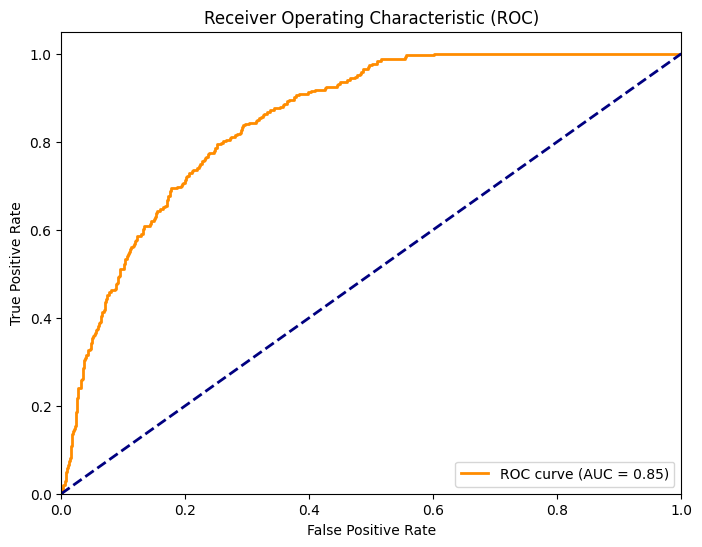

In [35]:
plot_roc(best_resnet_weightedLoss, norm_test_binary_loader, device, type='binary')

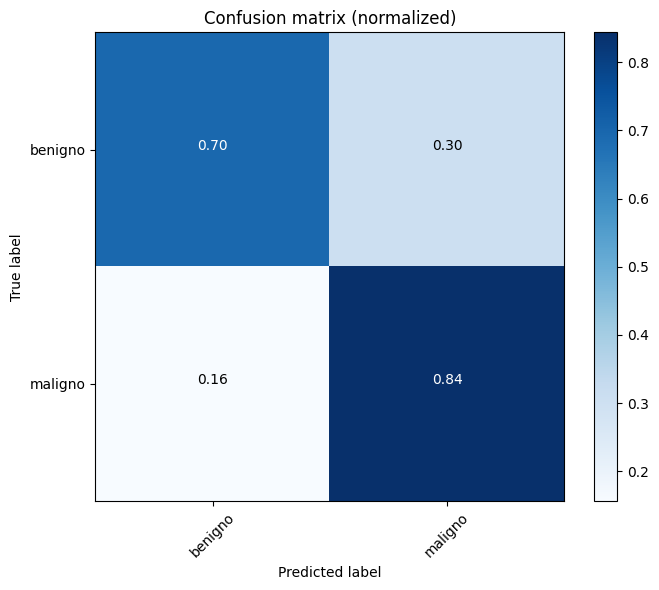

array([[0.69543568, 0.30456432],
       [0.15635179, 0.84364821]])

In [36]:
plot_confusion_matrix(best_resnet_weightedLoss, norm_test_binary_loader, device, classes=[0, 1], normalize=True, class_map={0: 'benigno', 1: 'maligno'})

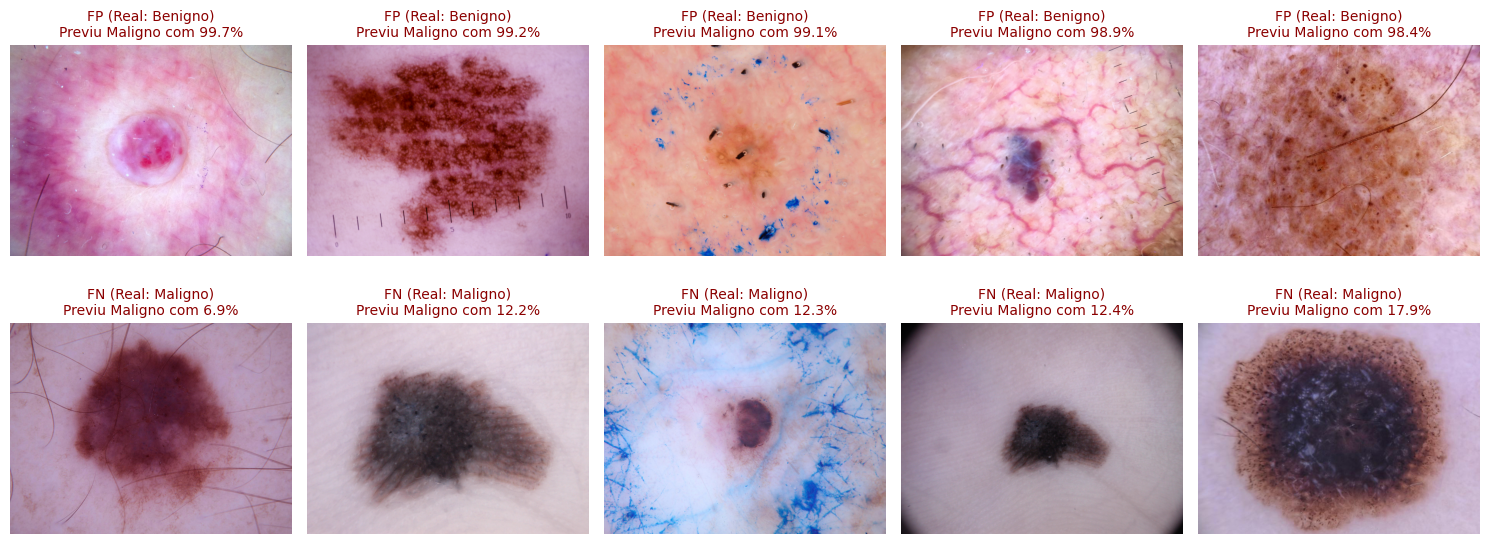

In [39]:
_ = plot_top_errors(best_resnet_weightedLoss, norm_test_binary_loader, device)

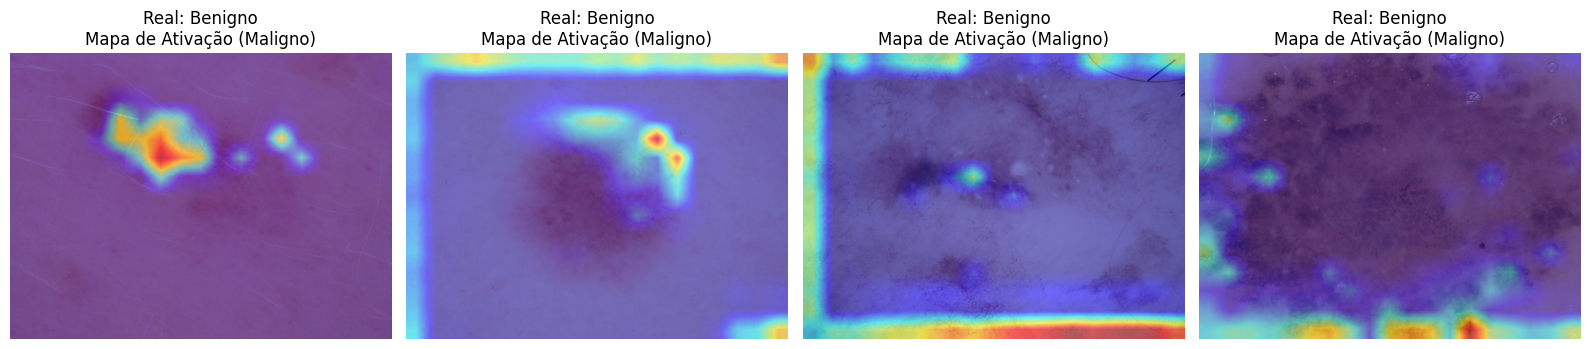

In [38]:
plot_gradcam(best_resnet_weightedLoss, norm_test_binary_loader, device)

### Amostragem ponderada

Podemos também alterar os Loaders, modificando a forma como os dados são apresentados para o modelo. Para isso usamos `WeightedRandomSampler`, que ajusta a probabilidade de um exemplo ser escolhido para um batch, garantindo que a rede veja a mesma proporção de imagens de cada classe.

In [ ]:
from torch.utils.data import WeightedRandomSampler

bng_weight = 1.0 / benign_qtd
mlg_weight = 1.0 / malignant_qtd

sample_weights = [
    bng_weight if label == 0 else mlg_weight
    for label in norm_train_binary_loader.dataset.targets # pyright: ignore[reportAttributeAccessIssue]
]

sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader_wrs = DataLoader(
    norm_train_binary_loader.dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4
)

In [ ]:
NUM_CLASSES = 2
model_resnet5 = ResNet18(num_classes=NUM_CLASSES).to(device)

epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet5.parameters(), lr=1e-3)

In [ ]:
history_resnet5 = fit(model_resnet5, train_loader_wrs, norm_val_binary_loader, optimizer, criterion, device, epochs, 'resnet_weightedSampler', True, patience=10)

In [ ]:
torch.save(model_resnet5.state_dict(), f'./{output_dir}/{student_run_tag}/model_resnet_weightedSampler.pth')

In [ ]:
best_resnet_weightedSampler = ResNet18(num_classes=2).to(device)
best_resnet_weightedSampler.load_state_dict(torch.load(f'./{output_dir}/{student_run_tag}/best_model_resnet_weightedSampler.pth', map_location=device))

_ = evaluate_classification(best_resnet_weightedSampler, norm_test_binary_loader)

In [ ]:
_ = plot_top_errors(best_resnet_weightedSampler, norm_test_binary_loader, device)

In [ ]:
plot_gradcam(best_resnet_weightedSampler, norm_test_binary_loader, device)

### Perda focal para classes desbalanceadas

In [ ]:
import torch.nn.functional as F

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(BinaryFocalLoss, self).__init__()
        self.alpha = alpha # Fator de balanceamento da classe (0.25 para a minoritária geralmente)
        self.gamma = gamma # Fator de foco (2.0 é o padrão)

    def forward(self, inputs, targets):
        # inputs: logits da ResNet
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss) # Probabilidade da predição estar correta
        
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

criterion = BinaryFocalLoss(alpha=0.8) # alpha alto foca na classe 1 (maligno)

In [66]:
torch.cuda.empty_cache()